In [8]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [10]:
df = pd.read_csv(r'C:\Users\User\Downloads\USvideos.csv', encoding='utf-8')
print('Raw shape:', df.shape)

with open(r'C:\Users\User\Downloads\US_category_id.json') as f:
    category_data = json.load(f)

category_map = {int(item['id']): item['snippet']['title'] for item in category_data['items']}
df['category_name'] = df['category_id'].map(category_map)

print('Unmapped category_ids:', df['category_name'].isna().sum())
df[['video_id', 'category_id', 'category_name']].head(3)

Raw shape: (40949, 16)
Unmapped category_ids: 0


,video_id,category_id,category_name
0,2kyS6SvSYSE,22,People & Blogs
1,1ZAPwfrtAFY,24,Entertainment
2,5qpjK5DgCt4,23,Comedy


In [11]:
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')
df['publish_time'] = pd.to_datetime(df['publish_time']).dt.tz_localize(None)

print('Trending date range:', df['trending_date'].min(), '->', df['trending_date'].max())
print('Publish time range:', df['publish_time'].min(), '->', df['publish_time'].max())

Trending date range: 2017-11-14 00:00:00 -> 2018-06-14 00:00:00
Publish time range: 2006-07-23 08:24:11 -> 2018-06-14 01:31:53


In [12]:
df['engagement_rate'] = (df['likes'] + df['dislikes'] + df['comment_count']) / df['views'] * 100
df['like_rate'] = df['likes'] / df['views'] * 100
df['days_to_trend'] = (df['trending_date'] - df['publish_time'].dt.normalize()).dt.days

df[['views', 'likes', 'dislikes', 'comment_count', 'engagement_rate', 'like_rate', 'days_to_trend']].describe()

,views,likes,dislikes,comment_count,engagement_rate,like_rate,days_to_trend
count,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04,40949.000000,40949.000000,40949.000000
mean,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03,4.048020,3.441298,16.810423
std,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04,3.024325,2.700864,146.014303
min,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02,1.915689,1.496722,3.000000
50%,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03,3.381086,2.827332,5.000000
75%,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03,5.379869,4.675136,9.000000
max,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06,33.025531,29.046646,4215.000000


In [13]:
before = df.shape[0]
df_unique = df.sort_values('trending_date').drop_duplicates('video_id', keep='first').copy()
print(f'Rows: {before} (all appearances) -> {df_unique.shape[0]} (unique videos)')
print(f'Avg trending appearances per video: {before / df_unique.shape[0]:.2f}')

Rows: 40949 (all appearances) -> 6351 (unique videos)
Avg trending appearances per video: 6.45


In [14]:
outlier_count = (df_unique['days_to_trend'] > 60).sum()
print(f"Videos with days_to_trend > 60: {outlier_count} ({outlier_count/df_unique.shape[0]:.1%} of unique videos)")
print(f"Median days_to_trend: {df_unique['days_to_trend'].median():.0f} days")
print(f"95th percentile: {df_unique['days_to_trend'].quantile(0.95):.0f} days")
df_unique.sort_values('days_to_trend', ascending=False)[['title', 'category_name', 'days_to_trend']].head(5)

Videos with days_to_trend > 60: 87 (1.4% of unique videos)
Median days_to_trend: 2 days
95th percentile: 6 days


,title,category_name,days_to_trend
16294,Budweiser - Original Whazzup? ad,Entertainment,4215
10710,Kramer vs Kramer-Clou Scene,Film & Animation,3563
2311,Behind The Sounds: That's Not Me,Music,3448
2553,SAOIRSE RONAN - MORONIC (IRONIC),Music,3398
1136,Amazon.com commercial Xmas 1999Magnetic Whale Art,Film & Animation,3176


In [15]:
## Pearson correlation across engagement metrics
corr_cols = ['views', 'likes', 'dislikes', 'comment_count', 'engagement_rate', 'days_to_trend']
corr_matrix = df_unique[corr_cols].corr(method='pearson')
corr_matrix.round(3)

,views,likes,dislikes,comment_count,engagement_rate,days_to_trend
views,1.000,0.761,0.396,0.600,0.057,-0.035
likes,0.761,1.000,0.360,0.806,0.319,-0.029
dislikes,0.396,0.360,1.000,0.680,0.097,-0.011
comment_count,0.600,0.806,0.680,1.000,0.258,-0.020
engagement_rate,0.057,0.319,0.097,0.258,1.000,-0.104
days_to_trend,-0.035,-0.029,-0.011,-0.020,-0.104,1.000


In [16]:
## Category benchmarking
category_kpi = df_unique.groupby('category_name').agg(
    avg_views=('views', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    avg_like_rate=('like_rate', 'mean'),
    n_videos=('video_id', 'count'),
).reset_index().sort_values('avg_views', ascending=False)

print(category_kpi)

            category_name     avg_views  avg_engagement_rate  avg_like_rate  \
7                   Music  1.387621e+06             8.234088       7.401756   
5                  Gaming  1.211844e+06             5.482981       4.380282   
9   Nonprofits & Activism  1.025217e+06             4.830642       3.744533   
4        Film & Animation  9.204330e+05             4.029484       3.397430   
14                 Sports  8.302815e+05             2.039082       1.611957   
3           Entertainment  8.171242e+05             3.843338       3.204845   
1                  Comedy  7.729546e+05             5.689227       4.971189   
10         People & Blogs  7.127675e+05             5.505346       4.700354   
12   Science & Technology  5.843225e+05             4.231290       3.580616   
6           Howto & Style  4.731389e+05             5.974671       5.144877   
0        Autos & Vehicles  4.063595e+05             2.254111       1.795106   
13                  Shows  3.923588e+05             

In [17]:
df_unique['publish_weekday'] = df_unique['publish_time'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_kpi = df_unique.groupby('publish_weekday').agg(
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    n_videos=('video_id', 'count'),
).reindex(weekday_order)

print(weekday_kpi)

                     avg_views  median_views  avg_engagement_rate  n_videos
publish_weekday                                                            
Monday           750340.857868      254444.0             4.383948       985
Tuesday          722556.557022      250242.0             4.574063      1061
Wednesday        677738.515953      268548.0             4.760349      1097
Thursday         713014.400000      291258.0             5.022438      1055
Friday           894334.042025      264767.0             5.238352      1047
Saturday         726031.160878      288208.0             4.875995       547
Sunday           859492.576029      296633.0             4.324283       559


In [18]:
from scipy.stats import f_oneway
weekday_groups = [df_unique[df_unique['publish_weekday'] == d]['views'].values for d in weekday_order]
f_stat, p_val = f_oneway(*weekday_groups)
print(f'One-way ANOVA across weekdays (views): F = {f_stat:.2f}, p = {p_val:.4f}')
print('Statistically significant weekday effect' if p_val < 0.05 else 'No statistically significant weekday effect')

One-way ANOVA across weekdays (views): F = 1.63, p = 0.1344
No statistically significant weekday effect


In [19]:
## Bonus
views_q75 = df_unique['views'].quantile(0.75)
views_q25 = df_unique['views'].quantile(0.25)
eng_q75 = df_unique['engagement_rate'].quantile(0.75)
eng_q25 = df_unique['engagement_rate'].quantile(0.25)

passive_viewers = df_unique[(df_unique['views'] > views_q75) & (df_unique['engagement_rate'] < eng_q25)]
niche_loyal = df_unique[(df_unique['views'] < views_q25) & (df_unique['engagement_rate'] > eng_q75)]

print(f'Passive-viewer videos (high views, low engagement): {passive_viewers.shape[0]}')
print(passive_viewers['category_name'].value_counts().head(5))
print()
print(f'Niche-loyal-audience videos (low views, high engagement): {niche_loyal.shape[0]}')
print(niche_loyal['category_name'].value_counts().head(5))

Passive-viewer videos (high views, low engagement): 335
category_name
Entertainment       128
Sports               72
Comedy               32
Film & Animation     25
News & Politics      20
Name: count, dtype: int64

Niche-loyal-audience videos (low views, high engagement): 352
category_name
Music             74
Entertainment     53
Howto & Style     50
People & Blogs    41
Comedy            36
Name: count, dtype: int64


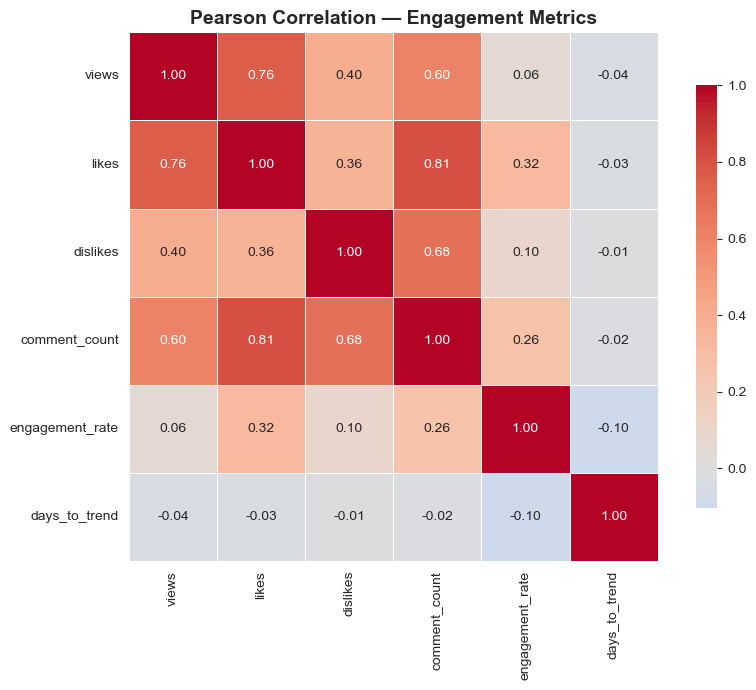

In [20]:
## Visualizations
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Pearson Correlation — Engagement Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/correlation_heatmap.png', dpi=150)
plt.show()

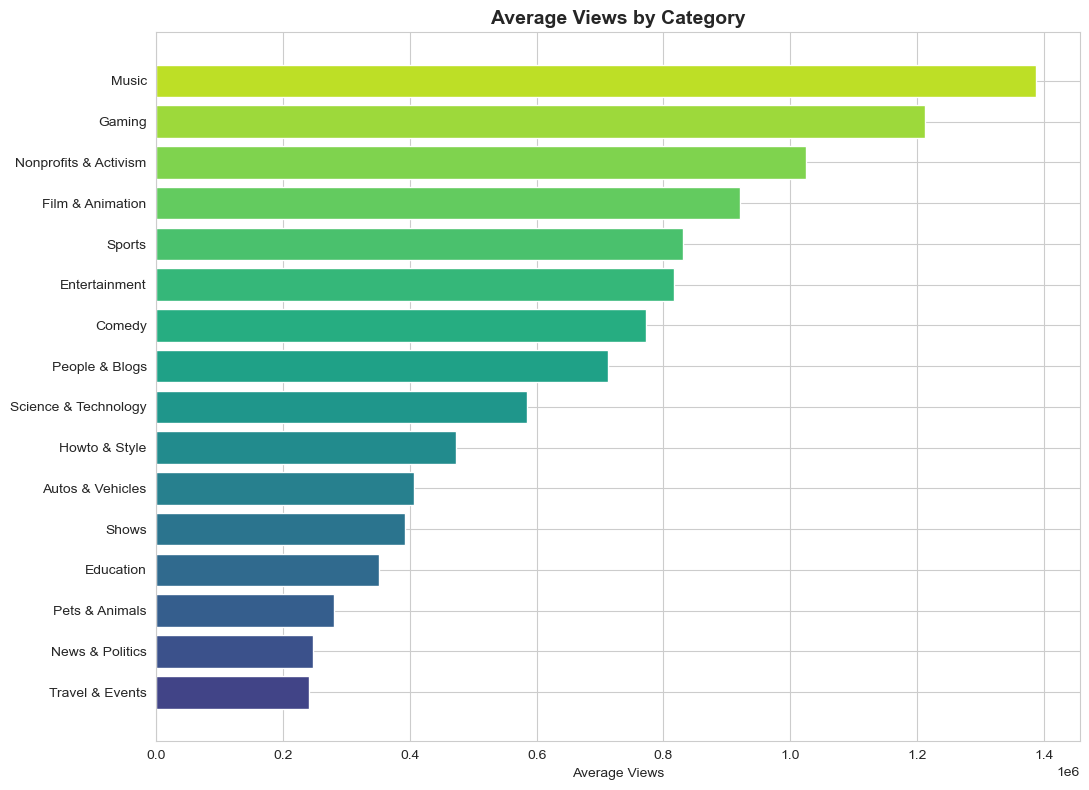

In [21]:
fig, ax = plt.subplots(figsize=(11, 8))
plot_data = category_kpi.sort_values('avg_views')
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(plot_data)))
ax.barh(plot_data['category_name'], plot_data['avg_views'], color=colors)
ax.set_title('Average Views by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Views')
plt.tight_layout()
plt.savefig('visuals/avg_views_by_category.png', dpi=150)
plt.show()

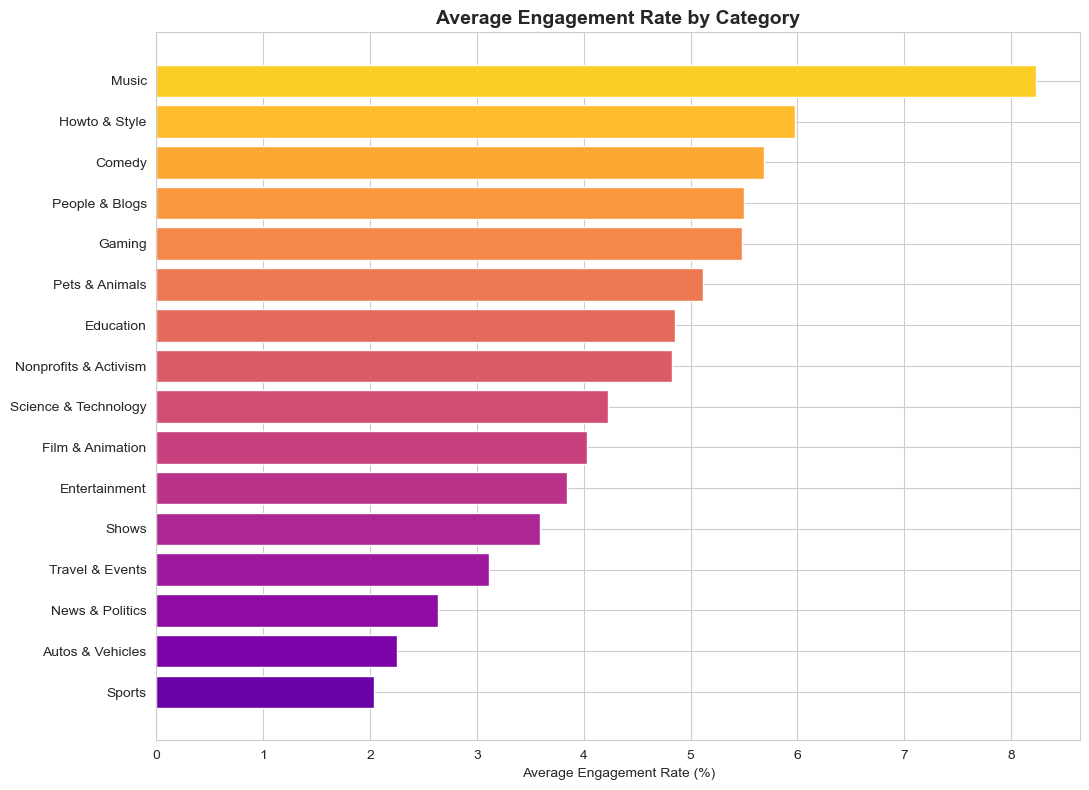

In [22]:
fig, ax = plt.subplots(figsize=(11, 8))
plot_data = category_kpi.sort_values('avg_engagement_rate')
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(plot_data)))
ax.barh(plot_data['category_name'], plot_data['avg_engagement_rate'], color=colors)
ax.set_title('Average Engagement Rate by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Engagement Rate (%)')
plt.tight_layout()
plt.savefig('visuals/engagement_rate_by_category.png', dpi=150)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_17732\2828620023.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=weekday_order, showfliers=False, patch_artist=True)


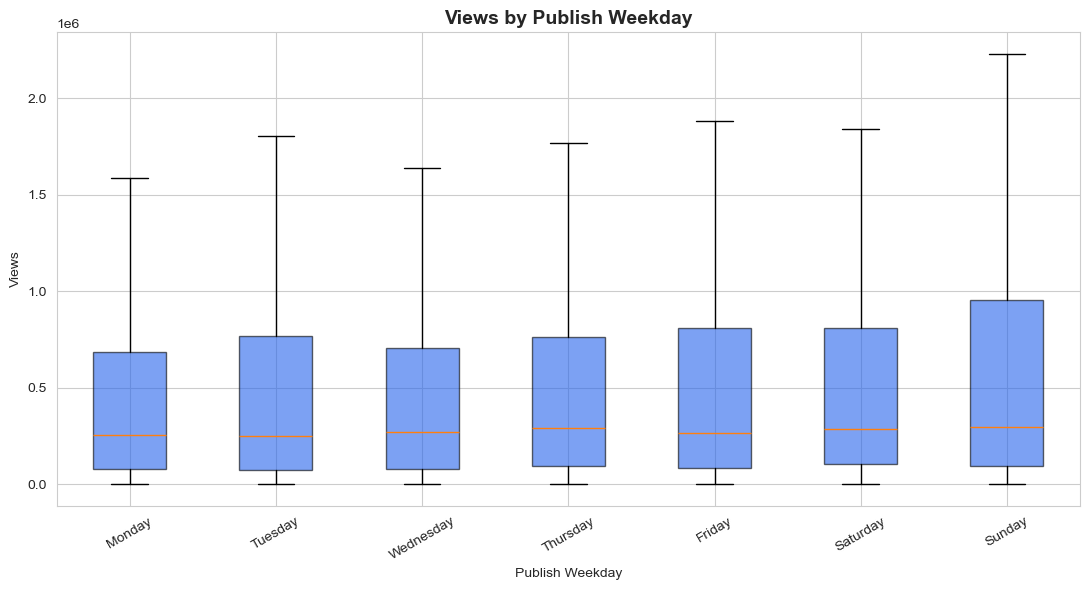

In [23]:
fig, ax = plt.subplots(figsize=(11, 6))
box_data = [df_unique[df_unique['publish_weekday'] == d]['views'].values for d in weekday_order]
bp = ax.boxplot(box_data, labels=weekday_order, showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#2563eb')
    patch.set_alpha(0.6)
ax.set_title('Views by Publish Weekday', fontsize=14, fontweight='bold')
ax.set_ylabel('Views')
ax.set_xlabel('Publish Weekday')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('visuals/views_by_publish_weekday.png', dpi=150)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))
top_categories = category_kpi.head(8)['category_name'].tolist()
plot_df = df_unique[df_unique['category_name'].isin(top_categories)]
sns.scatterplot(data=plot_df, x='views', y='engagement_rate', hue='category_name', alpha=0.6, ax=ax, palette='tab10')
ax.set_xscale('log')
ax.set_title('Views vs Engagement Rate (top 8 categories by volume)', fontsize=14, fontweight='bold')
ax.set_xlabel('Views (log scale)')
ax.set_ylabel('Engagement Rate (%)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('visuals/views_vs_engagement_scatter.png', dpi=150)
plt.show()

In [ ]:
category_kpi.to_csv('visuals/category_kpi.csv', index=False)
weekday_kpi.to_csv('visuals/weekday_kpi.csv')
corr_matrix.to_csv('visuals/correlation_matrix.csv')
top10_views.to_csv('visuals/top10_videos_by_views.csv', index=False)
print('KPI tables exported to visuals/')